# Forward and reverse-mode dynamics of a birefringent multimode fiber

The goal of this notebook and the other notebooks in this folder is to show an example of the usage of this code and various features. This notebook demonstrates the public PulsePropagation API on a retained GRIN-fiber example using CSV fiber assets bundled with the release. 

The first example demonstrates forward solving and gradient solving for a birefringent multimode soliton.

For a compact public run, this notebook makes two adjustments: I make the fiber shorter (to reduce overall simulation time and to make autodifferentiation feasible) and I do not multiply each mode (spatial + polarization) by random phases as to make a more easily reproducible output.

Loading packages below. 

In [1]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using DelimitedFiles
using CSV

  Activating project at `~/Desktop/FastDifferentiableMMNLO`


This is an example from Frank Wise's MATLAB code, birefringent_mm_soliton.m (the forward solves, not the adjoint part). Here I load some data from their simulation setup.

In [2]:
betas_biref = [5.847462729085851e+06	5.851435323667164e+06	5.841335866995176e+06	5.845308461576490e+06
4.878764128935511e+03	0	4.878836422580576e+03	0
-0.028100040576544	0	-0.028248131742058	0
1.518979580892188e-04	0	1.524304694210461e-04	0
-4.917494281128627e-07	0	-4.940312405234015e-07	0
2.315909039461211e-09	0	2.327945659939789e-09	0];

S_vals = reshape(readdlm("benchmark_data/birefringent_mm_soliton/S_tensors_10modes.csv",',',Float64;skipstart=1,)[:, 5],10, 10, 10, 10);

wavelengths = readdlm("benchmark_data/birefringent_mm_soliton/wavelength_nm.csv");
spec1 = readdlm("benchmark_data/birefringent_mm_soliton/spectrum_1.csv");
spec2 = readdlm("benchmark_data/birefringent_mm_soliton/spectrum_2.csv");
spec3 = readdlm("benchmark_data/birefringent_mm_soliton/spectrum_3.csv");
spec4 = readdlm("benchmark_data/birefringent_mm_soliton/spectrum_4.csv");

Let's instantiate basic simulation parameters.

In [3]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^11;
time_window = 50; # ps
λ0 = 1550e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength
λ_nm = 1e9*λ;

dofs = degrees_of_freedom(:time, :space, :polarization)
domain = MMGNLSEDomain(dofs, time_grid);


Fiber construction

In [4]:
num_modes = 2;
L_fiber = 2;
material = Silica()

S_tensor = S_vals[1:2,1:2,1:2,1:2];

betas = zeros((size(betas_biref,1)),2,2);
betas[:,1,1] = betas_biref[:,1];
betas[:,2,1] = betas_biref[:,3];
betas[:,1,2] = betas_biref[:,2];
betas[:,2,2] = betas_biref[:,4];

parameters = MMGNLSEParameters(domain; length=L_fiber, beta=TaylorBeta(betas), S=S_tensor, n2=material.n2, omega0 = ω0, raman = material.raman);


pulse_fwhm = 0.500
peak_power = 9394.39; # close enough to 5 nJ.
mode_coefficients = ones(2,2)

initial_field = gaussian_pulse(
    domain, num_modes;
    peak_power=peak_power, # W
    fwhm=pulse_fwhm,
    coefficients = mode_coefficients
);

In [5]:
dz = 0.0003;
solution = solve_mmgnlse(initial_field, parameters, dz; saveat=0.1);

In [6]:
At = get_temporal_field(solution,z=:final)
spec_out = get_spectral_field(solution,z=:final);

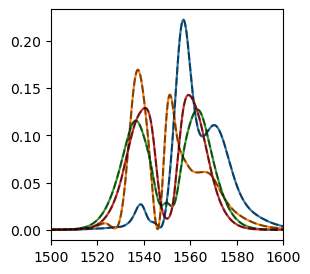

In [7]:
figure(figsize=(3,3))
plot(λ_nm,abs2.(spec_out[:,:,1]))
plot(λ_nm,abs2.(spec_out[:,:,2]))
plot(wavelengths, spec1, color="k", "--", alpha=0.5)
plot(wavelengths, spec2, color="k", "--", alpha=0.5)
plot(wavelengths, spec3, color="k", "--", alpha=0.5)
plot(wavelengths, spec4, color="k", "--", alpha=0.5)
xlim(1500,1600)
display(gcf())

In [8]:
maxind = argmax(abs2.(spec_out[:,1,1]))
filter = zero(spec_out[:,:,:]);
filter[maxind,1,1] = 1.0;
max_filt = real(filter);

obs = SpectralPhotonNumber(filter=max_filt)
n_out = value(obs, solution)

8.715882129207128e7

In [9]:
dz_adj = dz;
lambda_L = terminal_condition(obs, solution);
adjoint = solve_adjoint(lambda_L, parameters, dz; forward_solution = solution, units = :photon)

MMGNLSEAdjointSolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 3}, SpatialOverlap{Float64}, Float64, Float64, AnisotropicRaman{Float64}}, @NamedTuple{forward_solution::MMGNLSESolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}, Nothing}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 3}, SpatialOverlap{Float64}, Float64, Float64, AnisotropicRaman{Float64}}, Array{ComplexF64, 3}, RK4IP, @NamedTuple{integration_z::Vector{Float64}, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_prefactor::Array{ComplexF64, 3}, nonlinear_active::Bool, raman::@NamedTuple{ha::Vector{ComplexF64}, hb::Vector{ComplexF64}, fraction::Float64}}}}, integration_z::Vector{Float64}, frame::Symbol, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_prefactor::Array{ComplexF6

In [10]:
spectral_sensitivity = get_spectral_field(adjoint; z = :initial, units = :photon);

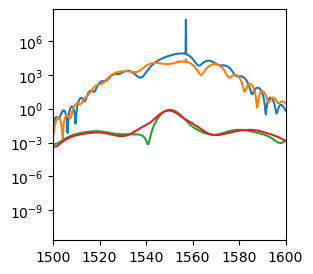

In [11]:
figure(figsize=(3,3))
semilogy(λ_nm, abs2.(spectral_sensitivity[:,:,1]))
semilogy(λ_nm, abs2.(spectral_sensitivity[:,:,2]))
xlim(1500,1600)
display(gcf())

In [12]:
dz_ad = 0.0003;
spectral_sensitivity_ad  = get_autodiff_adjoint(
    obs,
    initial_field,
    parameters,
    dz_ad; units=:photon
)

2048×2×2 Array{ComplexF64, 3}:
[:, :, 1] =
  -7.43583e-6-1.61942e-5im    -8.67499e-5-4.05766e-5im
   2.09989e-5-9.58458e-7im     6.46996e-5-7.20561e-5im
  -9.30335e-6+2.16524e-5im     5.00655e-5+8.48712e-5im
  -1.48385e-5-1.97356e-5im    -9.71079e-5+2.15443e-5im
     2.393e-5-3.00492e-6im     8.95927e-6-9.91228e-5im
  -9.96785e-6+1.91973e-5im     9.27528e-5+3.75498e-5im
  -7.71203e-6-1.56675e-5im    -6.38748e-5+8.00779e-5im
   1.18678e-5+3.35165e-6im    -6.02517e-5-8.80641e-5im
  -6.96671e-6+2.36621e-6im    0.000107382-3.16225e-5im
   4.81683e-6-1.90692e-6im    -4.91408e-6+0.000117157im
             ⋮               
      0.00024+0.00019858im     7.99124e-5+0.000312014im
   -8.3628e-5-0.000310024im   0.000152868-0.000285397im
 -0.000112013+0.000305298im  -0.000315006+0.000114049im
  0.000267498-0.000184094im   0.000330722+0.000125984im
 -0.000319776-5.31293e-6im   -0.000187371-0.000327701im
  0.000248702+0.000186087im   -5.84511e-5+0.000398565im
  -8.57034e-5-0.000285488im   0.00030415

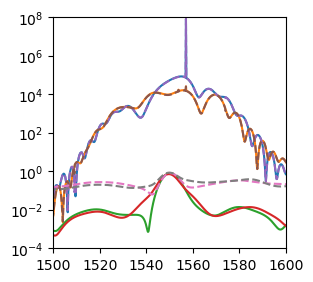

In [13]:
figure(figsize=(3,3))
semilogy(λ_nm, abs2.(spectral_sensitivity[:,:,1]))
semilogy(λ_nm, abs2.(spectral_sensitivity[:,:,2]))
semilogy(λ_nm, abs2.(spectral_sensitivity_ad[:,:,1]),"--")
semilogy(λ_nm, abs2.(spectral_sensitivity_ad[:,:,2]),"--")
xlim(1500,1600)
ylim(1e-4,1e8)
display(gcf())

Note that AD agrees well for the x polarization and not y. I suspect this is because the y-polarization sensitivities are very small (~5 orders of magnitude less, and so it is difficult to get them to perfectly agree.) Note also that AD is *very* memory-hungry and it is hard to push AD to shorter step sizes that are needed for convergence (0.1 mm) -- hence we can only establish a rough sense of internal agreement between adjoint and AD with this approach. Other examples can probe their agreement more finely.